<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Fase III: Multi-Stage Simulation Tasks</h3>

<ul>
  <li><b>Task 1:</b> Benchmark analítico 2 cuerpos (Tierra–satélite)</li>
  <li><b>Task 2:</b> Sistema restringido 3 cuerpos (Tierra–Luna–satélite)</li>
  <li><b>Task 3:</b> Expansión <i>N-body</i> 3D (Sol–Mercurio)</li>
</ul>

</div>


In [42]:
from matplotlib.offsetbox import AnnotationBbox, OffsetImage #permiten colocar imágenes dentro de una gráfica de Matplotlib
from PIL import Image, ImageDraw, ImageFont #PIL se utiliza para crear y manipular imágenes

def emoji_to_image(emoji, size=60):
    font_path = "/System/Library/Fonts/Apple Color Emoji.ttc"  #Se carga la fuente del sistema que contiene los emojis
    font = ImageFont.truetype(font_path, 48)

    canvas_size = 200
    img = Image.new("RGBA", (canvas_size, canvas_size), (255,255,255,0))
    draw = ImageDraw.Draw(img)

    draw.text((20,20), emoji, font=font)

    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)

    img = img.resize((size, size))
    return img

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D #habilita la creación de gráficos tridimensionales, necesarios para representar órbitas en el espacio

# constantes fisicas
G = 6.67430e-11 #Consatente de gravitación universal 
DAY = 86400.0 #duración de un día en segundos
AU = 1.495978707e11 #unidad astronómica

# masa de los cuerpos 
M_EARTH = 5.97219e24
M_MOON = 7.342e22
M_SAT = 4.19e5
M_SUN = 1.98847e30
M_MERCURY = 3.3011e23


In [44]:


def compute_accelerations(positions, masses, softening=0.0):  #calcular la aceleración gravitacional de cada cuerpo 
    n = positions.shape[0] #numero de cuerpos en el sistema 
    acc = np.zeros_like(positions, dtype=float) #matriz donde se almacenaran las aceleraciondes de cada cuerpo
    for i in range(n):
        r_ij = positions - positions[i] #Vector que apunta desde el cuerpo i hacia todos los demás cuerpos
        dist2 = np.sum(r_ij*r_ij, axis=1) + softening**2 #softening es un parámetro numérico que evita singularidades cuando dos cuerpos están extremadamente cerca
        inv_dist3 = np.zeros(n)  
        mask = dist2 > 0
        inv_dist3[mask] = dist2[mask]**(-1.5) #ley de gravitación de Newton en forma vectorial
        acc[i] = np.sum(r_ij * (G*masses*inv_dist3)[:,None], axis=0) #aceleración final
    return acc

def step_rk4(r, v, masses, dt): #Esta función avanza la simulación un paso en el tiempo usando el método numérico Runge-Kutta de cuarto orden
    a1 = compute_accelerations(r, masses)
    k1r, k1v = v, a1
    a2 = compute_accelerations(r + 0.5*dt*k1r, masses)
    k2r, k2v = v + 0.5*dt*k1v, a2
    a3 = compute_accelerations(r + 0.5*dt*k2r, masses)
    k3r, k3v = v + 0.5*dt*k2v, a3
    a4 = compute_accelerations(r + dt*k3r, masses)
    k4r, k4v = v + dt*k3v, a4
    r_next = r + (dt/6.0)*(k1r + 2*k2r + 2*k3r + k4r)
    v_next = v + (dt/6.0)*(k1v + 2*k2v + 2*k3v + k4v)
    return r_next, v_next

def simulate(positions0, velocities0, masses, dt, n_steps): #ejecuta la simulación temporal del sistema N-body almacenando la evolución de posiciones y velocidades.
    n = len(masses)
    pos = np.zeros((n_steps+1, n, 3))
    vel = np.zeros((n_steps+1, n, 3))
    t = np.arange(n_steps+1)*dt
    r, v = positions0.copy(), velocities0.copy()
    pos[0], vel[0] = r, v
    for k in range(1, n_steps+1):
        r, v = step_rk4(r, v, masses, dt)
        pos[k], vel[k] = r, v
    return {"time": t, "positions": pos, "velocities": vel}


<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Task 1</h3>

</div>

In [34]:
# Task 1: Tierra + satélite
alt = 420e3 ## Altura del satélite sobre la superficie terrestre
r_orbit = 6371e3 + alt ## Radio orbital medido desde el centro de la Tierra [m]
v_circ = np.sqrt(G*M_EARTH/r_orbit)

r0 = np.array([[0,0,0], [r_orbit,0,0]], dtype=float)
v0 = np.array([[0,0,0], [0,v_circ,0]], dtype=float)
masses = np.array([M_EARTH, M_SAT], dtype=float) # Masa del satélite [kg] MSAT, valor asumido para la simulación

dt = 10.0
n_steps = int(2*DAY/dt)
res1 = simulate(r0, v0, masses, dt, n_steps) # Resultado de la simulación del sistema Tierra-satélite


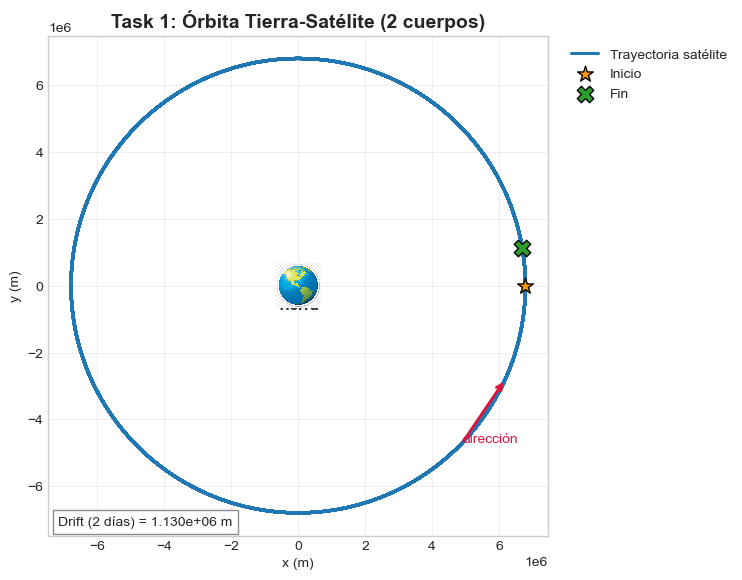

Task 1 drift posición (2 días): 1.130e+06 m


In [35]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import numpy as np
import matplotlib.pyplot as plt

# Cargamos imagen de la tierra
img_tierra = mpimg.imread("/Users/marav.angel/Downloads/tierra.png")

p = res1["positions"][:, 1, :] #Extraer la trayectoria del satélite
x, y = p[:, 0], p[:, 1]

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(7.5, 7.5))

# Trayectoria
ax.plot(x, y, color="#1f77b4", lw=2.2, label="Trayectoria satélite")

# Tierra icono
ab = AnnotationBbox(
    OffsetImage(img_tierra, zoom=0.09),  # ajusta 0.07 - 0.12 según tamaño
    (0, 0),
    frameon=False,
    zorder=6
)
ax.add_artist(ab)
ax.text(0, -7e5, "Tierra", ha="center", fontsize=11, fontweight="bold")

# Inicio y fin
ax.scatter(x[0], y[0], s=140, marker="*", color="#ff9900", edgecolor="black", zorder=7, label="Inicio")
ax.scatter(x[-1], y[-1], s=140, marker="X", color="#2ca02c", edgecolor="black", zorder=7, label="Fin")

# Flecha de dirección
k = len(x) // 8
ax.annotate(
    "",
    xy=(x[k + 30], y[k + 30]),
    xytext=(x[k], y[k]),
    arrowprops=dict(arrowstyle="->", lw=2, color="crimson")
)
ax.text(x[k], y[k], "dirección", color="crimson", fontsize=10)

ax.set_title("Task 1: Órbita Tierra-Satélite (2 cuerpos)", fontsize=14, weight="bold")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.3)

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

drift = np.linalg.norm(p[-1] - p[0])
ax.text(
    0.02, 0.02, f"Drift (2 días) = {drift:.3e} m",
    transform=ax.transAxes,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
)

plt.tight_layout()
plt.show()

print(f"Task 1 drift posición (2 días): {drift:.3e} m")




<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Task 2</h3>

</div>

In [36]:
# Task 2: Tierra-Luna-satélite
r_earth = np.array([0,0,0], dtype=float) #Posición y velocidad inicial de la tierra
v_earth = np.array([0,0,0], dtype=float)

r_moon = np.array([384400e3, 0, 0], dtype=float) #Posición y velocidad inicial de luna
v_moon = np.array([0, 1022.0, 0], dtype=float)

r_sat = np.array([200000e3, 0, 0], dtype=float)
v_sat = np.array([0, 1300.0, 0], dtype=float)

r0 = np.vstack([r_earth, r_moon, r_sat])
v0 = np.vstack([v_earth, v_moon, v_sat])
masses = np.array([M_EARTH, M_MOON, M_SAT], dtype=float)

dt = 60.0 #paso temporal de integración en seg
n_steps = int(30*DAY/dt) #total de pasos para simulas 30 dias 
res2 = simulate(r0, v0, masses, dt, n_steps)


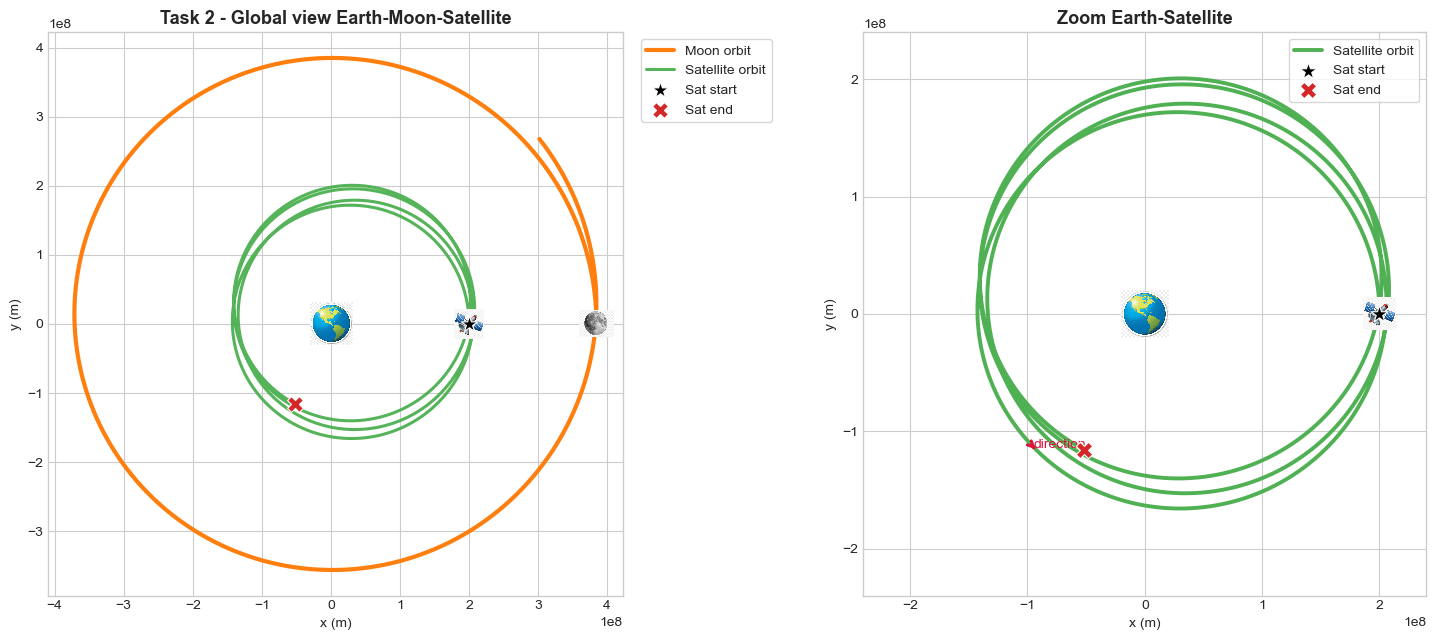

In [37]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Cargar imágenes
img_tierra = mpimg.imread("/Users/marav.angel/Downloads/tierra.png")
img_luna = mpimg.imread("/Users/marav.angel/Downloads/luna.png")
img_satelite = mpimg.imread("/Users/marav.angel/Downloads/satelite.png")

def poner_img(ax, img, x, y, zoom=0.08):
    ab = AnnotationBbox(OffsetImage(img, zoom=zoom), (x, y), frameon=False, zorder=10)
    ax.add_artist(ab)

p = res2["positions"]
xE, yE = p[:,0,0], p[:,0,1]   # Tierra
xM, yM = p[:,1,0], p[:,1,1]   # Luna
xS, yS = p[:,2,0], p[:,2,1]   # Satélite

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))

# -------- Panel izquierdo: Global --------
ax[0].plot(xM, yM, color="#ff7f0e", lw=3.0, label="Moon orbit")
ax[0].plot(xS, yS, color="#4caf50", lw=2.2, alpha=0.95, label="Satellite orbit")

# Íconos (dibujos)
poner_img(ax[0], img_tierra, xE[0], yE[0], zoom=0.085)
poner_img(ax[0], img_luna, xM[0], yM[0], zoom=0.070)
poner_img(ax[0], img_satelite, xS[0], yS[0], zoom=0.060)

# Inicio/fin satélite
ax[0].scatter(xS[0], yS[0], s=150, color="black", marker="*", edgecolor="white", linewidth=0.8, zorder=11, label="Sat start")
ax[0].scatter(xS[-1], yS[-1], s=130, color="#d62728", marker="X", edgecolor="white", linewidth=0.8, zorder=11, label="Sat end")

ax[0].set_title("Task 2 - Global view Earth-Moon-Satellite", fontsize=13, weight="bold")
ax[0].set_xlabel("x (m)")
ax[0].set_ylabel("y (m)")
ax[0].set_aspect("equal", adjustable="box")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=10, frameon=True)

#  Panel derecho: Zoom Tierra-Satélite 
ax[1].plot(xS, yS, color="#4caf50", lw=2.8, alpha=0.98, label="Satellite orbit")

# Íconos (dibujos)
poner_img(ax[1], img_tierra, xE[0], yE[0], zoom=0.095)
poner_img(ax[1], img_satelite, xS[0], yS[0], zoom=0.065)

# Inicio/fin satélite
ax[1].scatter(xS[0], yS[0], s=165, color="black", marker="*", edgecolor="white", linewidth=0.8, zorder=11, label="Sat start")
ax[1].scatter(xS[-1], yS[-1], s=140, color="#d62728", marker="X", edgecolor="white", linewidth=0.8, zorder=11, label="Sat end")

k = len(xS)//6
k2 = min(k + 20, len(xS)-1)
ax[1].annotate("", xy=(xS[k2], yS[k2]), xytext=(xS[k], yS[k]),
               arrowprops=dict(arrowstyle="->", lw=2.2, color="crimson"))
ax[1].text(xS[k], yS[k], "direction", color="crimson", fontsize=10)

r_zoom = 2.4e8
ax[1].set_xlim(-r_zoom, r_zoom)
ax[1].set_ylim(-r_zoom, r_zoom)
ax[1].set_title("Zoom Earth-Satellite", fontsize=13, weight="bold")
ax[1].set_xlabel("x (m)")
ax[1].set_ylabel("y (m)")
ax[1].set_aspect("equal", adjustable="box")
ax[1].legend(loc="upper right", fontsize=10, frameon=True)

plt.tight_layout()
plt.show()



<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Task 3</h3>

</div>

In [7]:
# Task 3: Tierra-Luna-satélite-Mercurio
r_earth = np.array([0, 0, 0], dtype=float) #posición inicial de la tierra
v_earth = np.array([0, 0, 0], dtype=float) #velocidad inicial de la tierra

r_moon = np.array([384400e3, 0, 0], dtype=float) #lo mismo pero luna
v_moon = np.array([0, 1022.0, 0], dtype=float)

r_sat = np.array([200000e3, 0, 0], dtype=float) #lo mismo pero satelite
v_sat = np.array([0, 1300.0, 0], dtype=float)

r_mercury = np.array([700000e3, 0, 0], dtype=float) #lo mimsmo pero mercurio 
v_mercury = np.array([0, 500.0, 0], dtype=float)

#Construcción del arreglo de posiciones iniciales
r0 = np.vstack([r_earth, r_moon, r_sat, r_mercury]) #vstack apila los vectores uno debajo del otro para formar una sola matriz de posiciones iniciales
v0 = np.vstack([v_earth, v_moon, v_sat, v_mercury])
masses = np.array([M_EARTH, M_MOON, M_SAT, M_MERCURY], dtype=float) #defino el vector de masas de los cuatro cuerpos

dt = 60.0  #el integrador actualiza posiciones y velocidades minuto a minuto
n_steps = int(30*DAY/dt)
res3 = simulate(r0, v0, masses, dt, n_steps) #simulate para integrar la evolución del sistema de cuatro cuerpos

In [39]:
import matplotlib.image as mpimg   #aca integramos de nuevo las imagenes para quede emoji 
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

img_tierra = mpimg.imread("/Users/marav.angel/Downloads/tierra.png")
img_luna = mpimg.imread("/Users/marav.angel/Downloads/luna.png")
img_satelite = mpimg.imread("/Users/marav.angel/Downloads/satelite.png")
img_mercurio = mpimg.imread("/Users/marav.angel/Downloads/mercurio.png")

def poner_img(ax, img, x, y, zoom=0.08):
    ab = AnnotationBbox(OffsetImage(img, zoom=zoom), (x, y), frameon=False, zorder=10)
    ax.add_artist(ab)


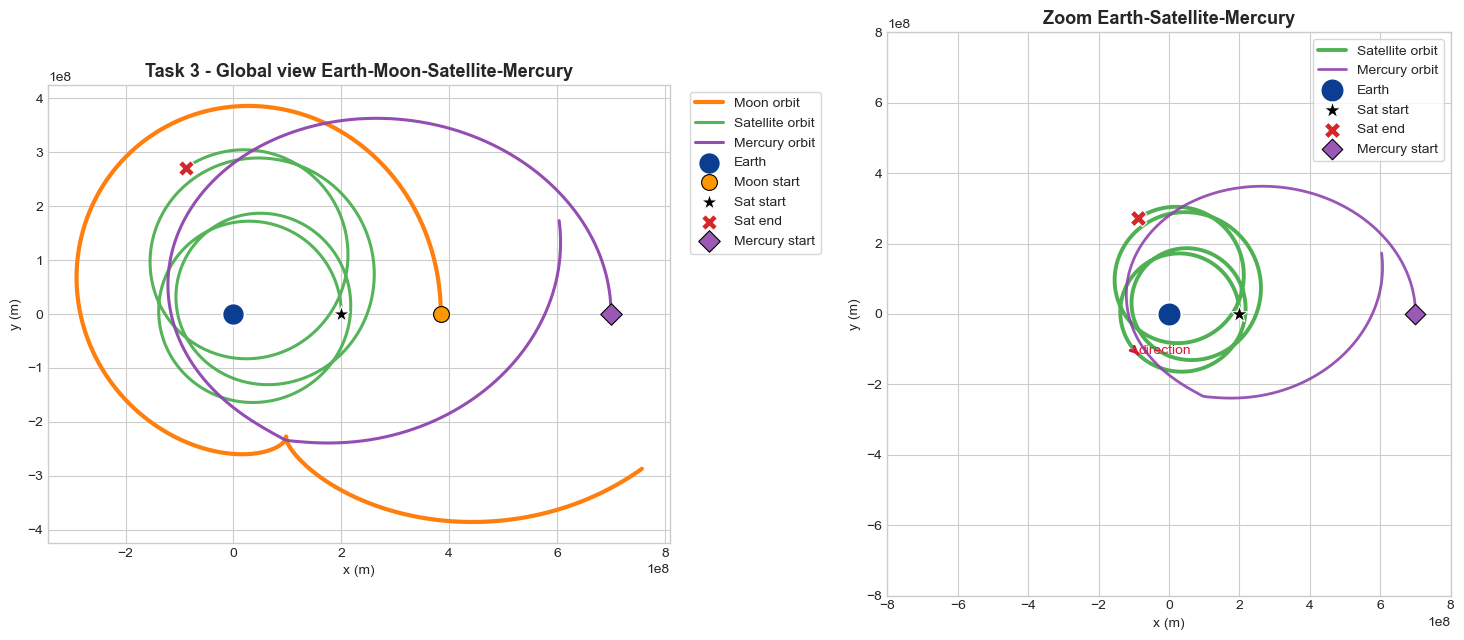

In [40]:
p = res3["positions"] #extraemos las posiciones del resultado
#Separar coordenadas de cada cuerpo
xE, yE = p[:,0,0], p[:,0,1] #coordenadas x , y tierra
xM, yM = p[:,1,0], p[:,1,1] #luna
xS, yS = p[:,2,0], p[:,2,1] #satelite
xMe, yMe = p[:,3,0], p[:,3,1] #mercurio 

plt.style.use("seaborn-v0_8-whitegrid") #estilo y figura
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))

#Graficar órbitas
ax[0].plot(xM, yM, color="#ff7f0e", lw=3.0, label="Moon orbit")
ax[0].plot(xS, yS, color="#4caf50", lw=2.2, alpha=0.95, label="Satellite orbit")
ax[0].plot(xMe, yMe, color="#8e44ad", lw=2.2, alpha=0.95, label="Mercury orbit")

ax[0].scatter(xE[0], yE[0], s=260, color="#0b3d91", edgecolor="white", linewidth=1.5, zorder=6, label="Earth")
ax[0].scatter(xM[0], yM[0], s=130, color="#ff9800", marker="o", edgecolor="black", linewidth=0.8, zorder=7, label="Moon start")
ax[0].scatter(xS[0], yS[0], s=150, color="black", marker="*", edgecolor="white", linewidth=0.8, zorder=7, label="Sat start")
ax[0].scatter(xS[-1], yS[-1], s=130, color="#d62728", marker="X", edgecolor="white", linewidth=0.8, zorder=7, label="Sat end")
ax[0].scatter(xMe[0], yMe[0], s=120, color="#9b59b6", marker="D", edgecolor="black", linewidth=0.8, zorder=7, label="Mercury start")

ax[0].set_title("Task 3 - Global view Earth-Moon-Satellite-Mercury", fontsize=13, weight="bold")
ax[0].set_xlabel("x (m)")
ax[0].set_ylabel("y (m)")
ax[0].set_aspect("equal", adjustable="box")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=10, frameon=True)

ax[1].plot(xS, yS, color="#4caf50", lw=2.8, alpha=0.98, label="Satellite orbit")
ax[1].plot(xMe, yMe, color="#8e44ad", lw=2.0, alpha=0.9, label="Mercury orbit")
ax[1].scatter(xE[0], yE[0], s=300, color="#0b3d91", edgecolor="white", linewidth=1.5, zorder=6, label="Earth")
ax[1].scatter(xS[0], yS[0], s=165, color="black", marker="*", edgecolor="white", linewidth=0.8, zorder=7, label="Sat start") #Marcar posiciones iniciales y finales
ax[1].scatter(xS[-1], yS[-1], s=140, color="#d62728", marker="X", edgecolor="white", linewidth=0.8, zorder=7, label="Sat end")
ax[1].scatter(xMe[0], yMe[0], s=110, color="#9b59b6", marker="D", edgecolor="black", linewidth=0.8, zorder=7, label="Mercury start")

k = len(xS)//6
ax[1].annotate("", xy=(xS[k+20], yS[k+20]), xytext=(xS[k], yS[k]),
               arrowprops=dict(arrowstyle="->", lw=2.2, color="crimson"))
ax[1].text(xS[k], yS[k], "direction", color="crimson", fontsize=10)

r_zoom = 8.0e8
ax[1].set_xlim(-r_zoom, r_zoom) #Configuración del panel global
ax[1].set_ylim(-r_zoom, r_zoom)
ax[1].set_title("Zoom Earth-Satellite-Mercury", fontsize=13, weight="bold")
ax[1].set_xlabel("x (m)")
ax[1].set_ylabel("y (m)")
ax[1].set_aspect("equal", adjustable="box")
ax[1].legend(loc="upper right", fontsize=10, frameon=True)

plt.tight_layout()
plt.show()



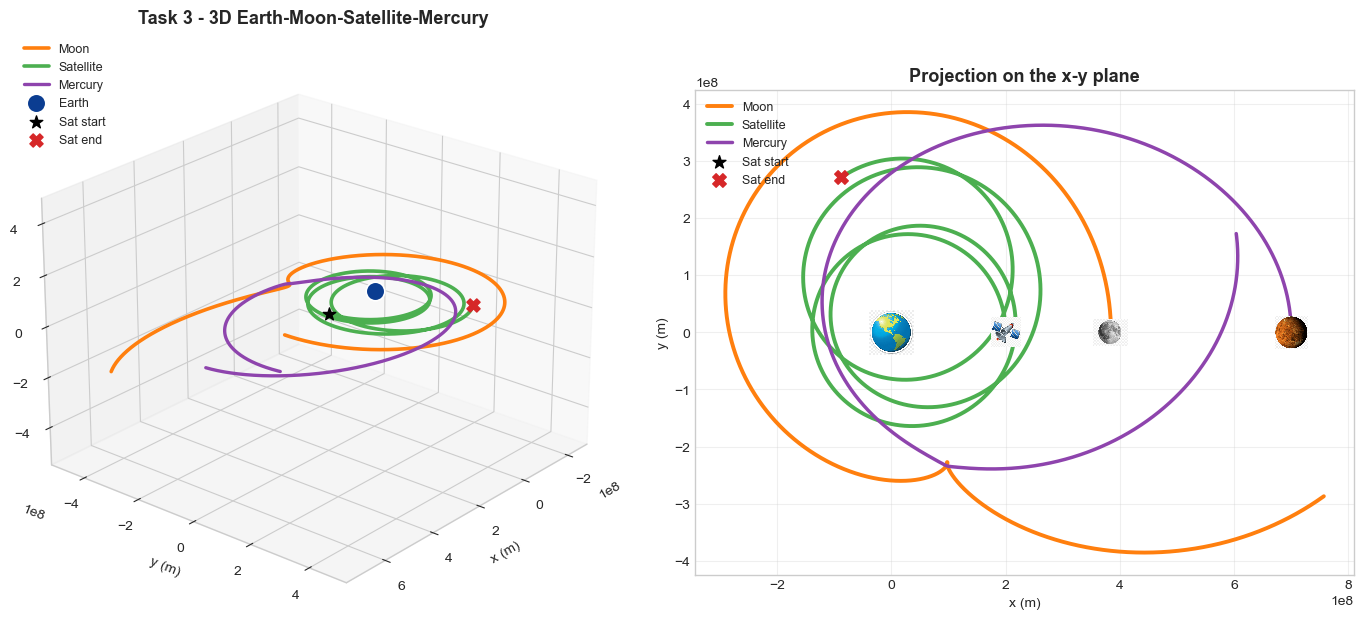

Task 3 satellite displacement after 30 days: 3.957e+08 m
Max |z| Mercury = 3.848e+07 m


In [41]:

# Task 3: Tierra-Luna-satélite-Mercurio

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

#condiciones inicales de la tierra
r_earth = np.array([0, 0, 0], dtype=float) #posición 
v_earth = np.array([0, 0, 0], dtype=float) #velocidad

r_moon = np.array([384400e3, 0, 0], dtype=float) 
v_moon = np.array([0, 1022.0, 0], dtype=float)

r_sat = np.array([200000e3, 0, 0], dtype=float)
v_sat = np.array([0, 1300.0, 0], dtype=float)

# Mercurio como cuarto cuerpo
r_mercury = np.array([700000e3, 0, 2.0e7], dtype=float)
v_mercury = np.array([0, 500.0, 40.0], dtype=float)

r0 = np.vstack([r_earth, r_moon, r_sat, r_mercury])  #Construcción del estado inicial del sistema
v0 = np.vstack([v_earth, v_moon, v_sat, v_mercury])
masses = np.array([M_EARTH, M_MOON, M_SAT, M_MERCURY], dtype=float)

dt = 60.0
n_steps = int(30 * DAY / dt)
res3 = simulate(r0, v0, masses, dt, n_steps)


# Cargar iconos
img_tierra = mpimg.imread("/Users/marav.angel/Downloads/tierra.png")
img_luna = mpimg.imread("/Users/marav.angel/Downloads/luna.png")
img_satelite = mpimg.imread("/Users/marav.angel/Downloads/satelite.png")
img_mercurio = mpimg.imread("/Users/marav.angel/Downloads/mercurio.png")  # crea/descarga este png

def poner_img(ax, img, x, y, zoom=0.08):
    ab = AnnotationBbox(OffsetImage(img, zoom=zoom), (x, y), frameon=False, zorder=12)
    ax.add_artist(ab)


# Gráfica final: 3D + proyección x-y
p = res3["positions"]

xE, yE, zE = p[:, 0, 0], p[:, 0, 1], p[:, 0, 2]
xM, yM, zM = p[:, 1, 0], p[:, 1, 1], p[:, 1, 2]
xS, yS, zS = p[:, 2, 0], p[:, 2, 1], p[:, 2, 2]
xMe, yMe, zMe = p[:, 3, 0], p[:, 3, 1], p[:, 3, 2]

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(14, 6.5))

# Panel 3D 
ax3d = fig.add_subplot(1, 2, 1, projection="3d")

ax3d.plot(xM, yM, zM, color="#ff7f0e", lw=2.6, label="Moon")
ax3d.plot(xS, yS, zS, color="#4caf50", lw=2.6, label="Satellite")
ax3d.plot(xMe, yMe, zMe, color="#8e44ad", lw=2.4, label="Mercury")

# En 3D dejamos marcadores matplotlib no pone PNG 2D bien en 3D
ax3d.scatter(xE[0], yE[0], zE[0], s=180, color="#0b3d91",
             edgecolor="white", linewidth=1.2, label="Earth")
ax3d.scatter(xS[0], yS[0], zS[0], s=90, color="black", marker="*", label="Sat start")
ax3d.scatter(xS[-1], yS[-1], zS[-1], s=90, color="#d62728", marker="X", label="Sat end")

ax3d.set_title("Task 3 - 3D Earth-Moon-Satellite-Mercury", fontsize=13, weight="bold")
ax3d.set_xlabel("x (m)")
ax3d.set_ylabel("y (m)")
ax3d.set_zlabel("z (m)")
ax3d.view_init(elev=24, azim=40)

all_x = np.concatenate([xE, xM, xS, xMe])
all_y = np.concatenate([yE, yM, yS, yMe])
all_z = np.concatenate([zE, zM, zS, zMe])

xmid = 0.5 * (all_x.max() + all_x.min())
ymid = 0.5 * (all_y.max() + all_y.min())
zmid = 0.5 * (all_z.max() + all_z.min())

rmax = max(
    all_x.max() - all_x.min(),
    all_y.max() - all_y.min(),
    all_z.max() - all_z.min()
) / 2.0

ax3d.set_xlim(xmid - rmax, xmid + rmax)
ax3d.set_ylim(ymid - rmax, ymid + rmax)
ax3d.set_zlim(zmid - rmax, zmid + rmax)
ax3d.legend(loc="upper left", fontsize=9)

# Proyección XY 
ax2 = fig.add_subplot(1, 2, 2)

ax2.plot(xM, yM, color="#ff7f0e", lw=2.8, label="Moon")
ax2.plot(xS, yS, color="#4caf50", lw=2.8, label="Satellite")
ax2.plot(xMe, yMe, color="#8e44ad", lw=2.5, label="Mercury")

# Iconos (dibujos) en XY
poner_img(ax2, img_tierra, xE[0], yE[0], zoom=0.090)
poner_img(ax2, img_luna, xM[0], yM[0], zoom=0.070)
poner_img(ax2, img_satelite, xS[0], yS[0], zoom=0.060)
poner_img(ax2, img_mercurio, xMe[0], yMe[0], zoom=0.065)

# Inicio/fin satélite
ax2.scatter(xS[0], yS[0], s=95, color="black", marker="*", label="Sat start", zorder=11)
ax2.scatter(xS[-1], yS[-1], s=95, color="#d62728", marker="X", label="Sat end", zorder=11)

ax2.set_title("Projection on the x-y plane", fontsize=13, weight="bold")
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")
ax2.set_aspect("equal", adjustable="box")
ax2.grid(alpha=0.3)
ax2.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

# Métrica simple adicional
sat_shift = np.linalg.norm(p[-1, 2, :] - p[0, 2, :])
print(f"Task 3 satellite displacement after 30 days: {sat_shift:.3e} m")
print(f"Max |z| Mercury = {np.max(np.abs(zMe)):.3e} m")


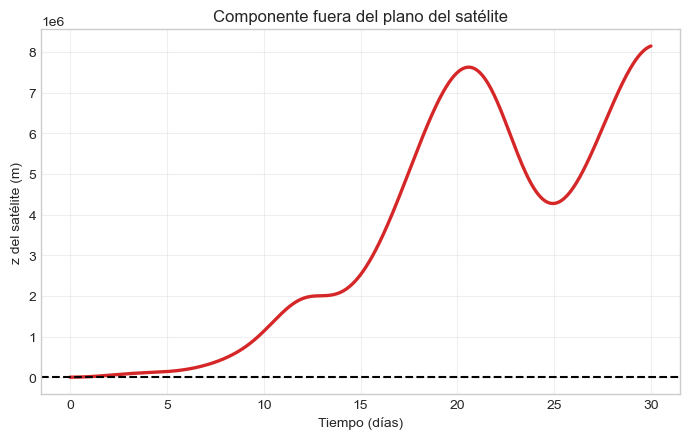

Max |z| satélite = 8.143e+06 m


In [16]:
# ===== Análisis fuera del plano =====

zS = res3["positions"][:, 2, 2]
t_days = np.arange(len(zS)) * dt / DAY #Tiempo de la simulación convertido a días

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(7,4.5))

plt.plot(t_days, zS, lw=2.4, color="#d62728")
plt.axhline(0, color="black", ls="--")

plt.xlabel("Tiempo (días)")
plt.ylabel("z del satélite (m)")
plt.title("Componente fuera del plano del satélite")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max |z| satélite = {np.max(np.abs(zS)):.3e} m") # Máxima desviación del satélite respecto al plano orbital

<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top:0;">💖 Para analizar el efecto fuera del plano observé la componente z del satélite.</h3>

Se ve que la trayectoria deja de ser completamente plana y aparece una desviación vertical con el tiempo.  
Esto muestra cómo, al incluir más cuerpos en el sistema, las perturbaciones gravitacionales modifican la posición del satélite también en la dirección z.

</div>

<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Conclusión de Fase III (Task 1, 2 y 3)</h3>

Estos tres ejercicios muestran claramente cómo el modelo va escalando en complejidad, pero manteniendo consistencia física en cada etapa.  

En <b>Task 1 (2 cuerpos)</b> se recupera el caso base: una órbita Tierra-satélite prácticamente circular, donde además se puede medir el <i>drift</i> numérico y establecer qué tan bien se comporta el integrador.  

En <b>Task 2 (3 cuerpos restringido)</b> ya no estamos en el mundo ideal: la Luna introduce perturbaciones visibles en la trayectoria, lo que confirma que el modelo responde correctamente a interacciones gravitacionales adicionales.  

En <b>Task 3 (sistema de cuatro cuerpos)</b> Agregue a Mercurio al sistema Tierra–Luna–satélite. Con esto el modelo deja de ser un problema de tres cuerpos y pasa a incluir una perturbación gravitacional adicional. Aunque Mercurio no domina la dinámica del sistema, su presencia introduce pequeñas desviaciones en la trayectoria del satélite, mostrando cómo en problemas N-body incluso masas relativamente alejadas pueden afectar la evolución orbital. Esto confirma que el modelo responde de forma coherente al aumentar la complejidad del sistema.
<br>

En conjunto, los resultados no solo son físicamente coherentes,sino que muestran que el solver es robusto: pasa de un problema clásico de 2 cuerpos a configuraciones N-body más complejas sin perder estabilidad ni consistencia.
</div>
